Dataset Loaded Successfully
   patient_id   age  gender region   bmi  blood_pressure  cholesterol  \
0           1  25.0    Male  North  22.5             120        180.0   
1           2  34.0  Female  South  28.4             135        210.0   
2           3   NaN    Male   East  31.2             140        220.0   
3           4  45.0     NaN   West  27.8             145        250.0   
4           5  52.0  Female    NaN  35.6             180        290.0   

   glucose  disease_risk  
0     95.0             0  
1    105.0             1  
2      NaN             1  
3    110.0             1  
4    180.0             1  
Shape of Dataset
(15, 9)
Column Names
Index(['patient_id', 'age', 'gender', 'region', 'bmi', 'blood_pressure',
       'cholesterol', 'glucose', 'disease_risk'],
      dtype='object')
Data Types
patient_id          int64
age               float64
gender             object
region             object
bmi               float64
blood_pressure      int64
cholesterol       flo

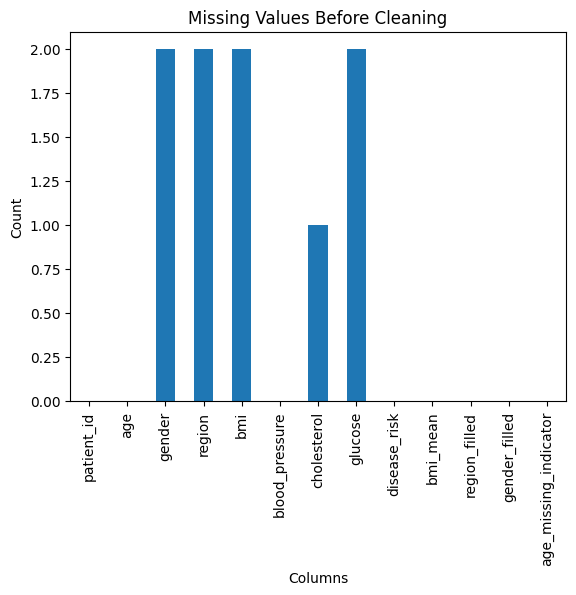

Outliers using Z Score Method
Empty DataFrame
Columns: [patient_id, age, gender, region, bmi, blood_pressure, cholesterol, glucose, disease_risk, bmi_mean, region_filled, gender_filled, age_missing_indicator]
Index: []
Outliers using IQR Method
    patient_id   age gender region   bmi  blood_pressure  cholesterol  \
14          15  65.0   Male  North  45.8             270        420.0   

    glucose  disease_risk  bmi_mean region_filled gender_filled  \
14    350.0             1      45.8         North          Male   

    age_missing_indicator  
14                      0  
Percentile Method Applied
0      95.420000
1     105.000000
2     161.769231
3     110.000000
4     180.000000
5     100.000000
6     320.000000
7      98.000000
8     115.000000
9     108.000000
10    280.000000
11    161.769231
12    140.000000
13    102.000000
14    345.800000
Name: glucose_percentile, dtype: float64
Winsorization Applied
0     180.000000
1     210.000000
2     220.000000
3     250.000000
4    

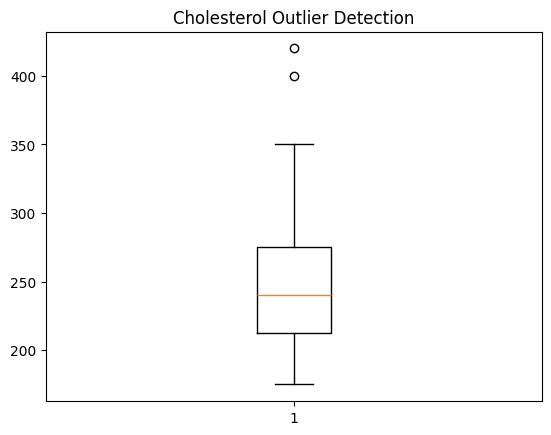

Remaining Missing Values
patient_id        0
age               0
gender            0
region            0
bmi               0
blood_pressure    0
cholesterol       0
glucose           0
disease_risk      0
dtype: int64
Original Dataset Summary
       patient_id        age        bmi  blood_pressure  cholesterol  \
count   15.000000  15.000000  13.000000        15.00000    14.000000   
mean     8.000000  41.933333  31.061538       159.00000   259.285714   
std      4.472136  12.097619   7.364163        47.44621    78.565434   
min      1.000000  25.000000  22.500000       118.00000   175.000000   
25%      4.500000  32.500000  26.100000       131.00000   211.250000   
50%      8.000000  39.000000  28.400000       140.00000   235.000000   
75%     11.500000  50.000000  35.600000       165.00000   282.500000   
max     15.000000  65.000000  45.800000       270.00000   420.000000   

          glucose  disease_risk   bmi_mean  age_missing_indicator  \
count   13.000000     15.000000  15.000

In [4]:
# ======================================================
# DATA PREPROCESSING AND FEATURE ENGINEERING PROJECT
# ======================================================

# QUESTION 1 : Import Required Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

from sklearn.impute import SimpleImputer
from sklearn.impute import KNNImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

from scipy.stats import zscore
from scipy.stats.mstats import winsorize


# QUESTION 2 : Load Dataset

df = pd.read_csv("patient_health_records.csv")

print("Dataset Loaded Successfully")
print(df.head())


# QUESTION 3 : Display Basic Dataset Information

print("Shape of Dataset")
print(df.shape)

print("Column Names")
print(df.columns)

print("Data Types")
print(df.dtypes)


# QUESTION 4 : Check Missing Values

print("Missing Values in Dataset")
print(df.isnull().sum())


# QUESTION 5 : Calculate Missing Value Percentage

missing_percent = (df.isnull().sum() / len(df)) * 100

print("Missing Percentage")
print(missing_percent)


# ======================================================
# PART A : MISSING VALUE HANDLING
# ======================================================


# QUESTION 6 : Apply Mean Imputation on BMI Column

mean_imputer = SimpleImputer(strategy="mean")

df["bmi_mean"] = mean_imputer.fit_transform(df[["bmi"]])

print("BMI Missing Values Filled using Mean")
print(df[["bmi","bmi_mean"]])


# QUESTION 7 : Apply Most Frequent Imputation on Region Column

region_imputer = SimpleImputer(strategy="most_frequent")

df["region_filled"] = region_imputer.fit_transform(df[["region"]]).ravel()

print("Region Missing Values Filled")
print(df[["region","region_filled"]])


# QUESTION 8 : Apply Most Frequent Imputation on Gender Column

gender_imputer = SimpleImputer(strategy="most_frequent")

df["gender_filled"] = gender_imputer.fit_transform(df[["gender"]]).ravel()

print("Gender Missing Values Filled")
print(df[["gender","gender_filled"]])


# QUESTION 9 : Create Missing Indicator for Age Column

df["age_missing_indicator"] = df["age"].isnull().astype(int)

print("Missing Indicator Created")
print(df[["age","age_missing_indicator"]])


# QUESTION 10 : Apply Random Sample Imputation on Age Column

random_sample = df["age"].dropna().sample(df["age"].isnull().sum(), random_state=42)

df.loc[df["age"].isnull(),"age"] = random_sample.values

print("Age Missing Values Filled using Random Sample")
print(df["age"])


# QUESTION 11 : Apply KNN Imputer

knn_data = df[["age","bmi","cholesterol","glucose"]]

knn = KNNImputer(n_neighbors=3)

knn_result = knn.fit_transform(knn_data)

knn_df = pd.DataFrame(knn_result, columns=knn_data.columns)

print("KNN Imputation Result")
print(knn_df)


# QUESTION 12 : Apply MICE Algorithm

mice = IterativeImputer(random_state=42)

mice_result = mice.fit_transform(knn_data)

mice_df = pd.DataFrame(mice_result, columns=knn_data.columns)

print("MICE Algorithm Result")
print(mice_df)


# QUESTION 13 : Visualize Missing Values Before Cleaning

df.isnull().sum().plot(kind="bar")

plt.title("Missing Values Before Cleaning")
plt.xlabel("Columns")
plt.ylabel("Count")

plt.show()


# ======================================================
# PART B : OUTLIER DETECTION AND HANDLING
# ======================================================


# QUESTION 14 : Detect Outliers using Z Score Method

cholesterol_clean = df["cholesterol"].fillna(df["cholesterol"].mean())

z_scores = np.abs(zscore(cholesterol_clean))

outliers = df[z_scores > 3]

print("Outliers using Z Score Method")
print(outliers)


# QUESTION 15 : Detect Outliers using IQR Method

Q1 = df["bmi_mean"].quantile(0.25)
Q3 = df["bmi_mean"].quantile(0.75)

IQR = Q3 - Q1

lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

outliers_iqr = df[(df["bmi_mean"] < lower_limit) | (df["bmi_mean"] > upper_limit)]

print("Outliers using IQR Method")
print(outliers_iqr)


# QUESTION 16 : Apply Percentile Method on Glucose Column

glucose_clean = df["glucose"].fillna(df["glucose"].mean())

lower = glucose_clean.quantile(0.01)
upper = glucose_clean.quantile(0.99)

df["glucose_percentile"] = np.where(
    glucose_clean < lower,
    lower,
    np.where(glucose_clean > upper, upper, glucose_clean)
)

print("Percentile Method Applied")
print(df["glucose_percentile"])


# QUESTION 17 : Apply Winsorization on Cholesterol Column

chol = df["cholesterol"].fillna(df["cholesterol"].mean())

df["cholesterol_winsor"] = winsorize(
    chol,
    limits=[0.05,0.05]
)

print("Winsorization Applied")
print(df["cholesterol_winsor"])


# QUESTION 18 : Create Boxplot for Outlier Visualization

plt.boxplot(df["cholesterol"].fillna(df["cholesterol"].mean()))

plt.title("Cholesterol Outlier Detection")

plt.show()


# ======================================================
# PART C : CREATE FINAL CLEAN DATASET
# ======================================================


# QUESTION 19 : Create Final Dataset

final_df = df.copy()

final_df["bmi"] = final_df["bmi_mean"]
final_df["region"] = final_df["region_filled"]
final_df["gender"] = final_df["gender_filled"]
final_df["cholesterol"] = final_df["cholesterol_winsor"]
final_df["glucose"] = final_df["glucose_percentile"]


# QUESTION 20 : Remove Temporary Columns

final_df = final_df.drop(
    columns=[
        "bmi_mean",
        "region_filled",
        "gender_filled",
        "glucose_percentile",
        "cholesterol_winsor",
        "age_missing_indicator"
    ]
)


# QUESTION 21 : Check Remaining Missing Values

print("Remaining Missing Values")
print(final_df.isnull().sum())


# QUESTION 22 : Display Original Dataset Summary

print("Original Dataset Summary")
print(df.describe())


# QUESTION 23 : Display Final Cleaned Dataset Summary

print("Cleaned Dataset Summary")
print(final_df.describe())


# QUESTION 24 : Save Final Dataset as CSV File

final_df.to_csv(
    "cleaned_patient_dataset.csv",
    index=False
)

print("Final Dataset Saved Successfully")


# QUESTION 25 : Display Final Dataset Preview

print("Final Dataset Preview")
print(final_df.head(20))


# QUESTION 26 : Project Conclusion

print("PROJECT CONCLUSION")

print("1. Missing values handled using Mean, Most Frequent, Random Sample, KNN and MICE")

print("2. Outliers detected using Z Score and IQR Method")

print("3. Extreme values treated using Percentile and Winsorization")

print("4. Final cleaned dataset created successfully")

print("5. Dataset ready for machine learning and analysis")